# Line Delay Rankings

Ranks lines separately by late-only and early-only delay.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "line_delay_rankings",
    PROJECT_ROOT / "analysis" / "line-delay-rankings.py",
)
rankings = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rankings)

DB = PROJECT_ROOT / "data" / "foli.db"
MIN_OBSERVATIONS = 50
LIMIT = 10
TIMEZONE = "Europe/Helsinki"
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

df = rankings.load_observations(Args)
buckets = rankings.prepare_buckets(Args, df)
late = rankings.rank_late(buckets, MIN_OBSERVATIONS, LIMIT)
early = rankings.rank_early(buckets, MIN_OBSERVATIONS, LIMIT)
late

,line_ref,line_name,bucket_count,raw_poll_count,signed_mean_delay_min,median_delay_min,p75_delay_min,p90_delay_min,p95_delay_min,pct_over_3_min_late,pct_over_5_min_late
51,612,612,280,623,6.65,5.01,13.59,16.68,17.80,62.86,50.36
33,41,41,419,1499,3.22,1.50,5.05,13.82,16.16,36.04,25.78
53,615,615,682,1288,2.55,2.84,7.14,13.35,15.40,48.53,32.11
34,42,42,192,545,3.36,1.49,7.46,11.27,12.86,44.79,27.08
69,720,720,272,612,4.59,4.68,6.93,10.30,10.93,65.07,47.06
52,614,614,472,1090,4.29,3.87,7.08,10.00,12.55,57.63,41.53
36,43,43,630,1817,3.09,1.68,4.77,9.28,11.76,37.46,23.49
68,72,72,557,975,3.13,2.58,6.07,8.45,9.86,45.06,32.68
13,24,24,6060,11688,2.31,1.03,4.49,8.08,10.83,34.93,21.30
14,25,25,3195,6025,1.96,1.17,4.28,7.09,9.84,33.21,19.62


In [3]:
early

,line_ref,line_name,bucket_count,raw_poll_count,signed_mean_delay_min,median_delay_min,pct_early,pct_over_1_min_early,pct_over_3_min_early,median_early_min_abs,p90_early_min_abs
76,76,76,117,547,-4.77,0.00,47.01,27.35,11.97,1.22,58.50
122,P6,P6,275,898,-6.89,-5.50,93.45,81.45,69.45,5.98,15.11
87,903,903,236,880,-1.29,0.00,41.95,31.78,21.19,3.67,14.25
53,615,615,682,1288,2.55,2.84,33.28,26.39,20.53,5.63,12.78
86,901,901,1435,7599,-0.97,0.00,49.90,37.84,23.76,2.72,11.66
105,L9,L9,58,301,-1.92,-0.72,55.17,48.28,41.38,5.59,9.83
107,N10,N10,191,908,-2.73,-3.07,69.11,65.97,50.26,5.15,8.89
81,801,801,10555,24266,-0.56,0.00,49.55,37.00,20.08,2.27,8.87
103,L6,L6,193,706,-1.41,-0.57,55.44,45.08,29.53,3.33,7.87
77,77,77,344,667,-2.33,-2.07,64.53,59.01,44.48,5.18,7.81


Text(0, 0.5, 'Line')

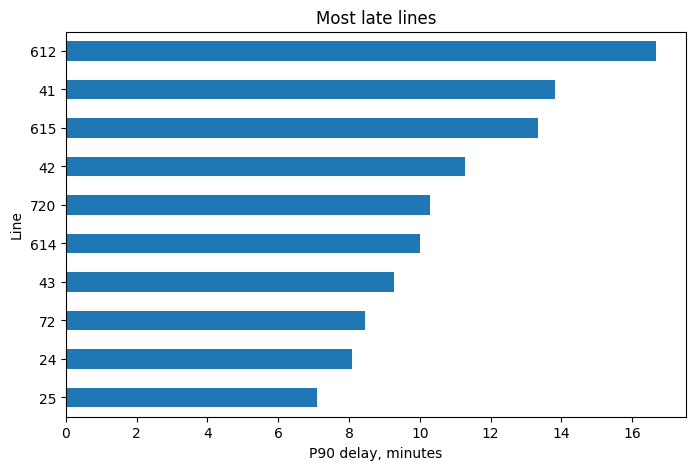

In [4]:
ax = late.sort_values("p90_delay_min").plot.barh(
    x="line_ref",
    y="p90_delay_min",
    legend=False,
    figsize=(8, 5),
    title="Most late lines",
)
ax.set_xlabel("P90 delay, minutes")
ax.set_ylabel("Line")